In [162]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys         
import xarray as xr
import NooneCurves as NC 
import pandas as pd
import seaborn as sns

In [163]:
# Some initial values for testing
del0 = -400.    # Try -360 ....
delp = -30. 
eta  = 0.995
hsrc = 0.80 
nn   = 1000     # It needs to be this large to get precision in the searches
pcld = 85000.
ps = 1000.e2                    # approximate surface pressure
q0   = 0.9 
qmin = 11.
tsrc = 300. 

In [178]:
inst = 'TROPESS'
band = 'S'

#tes_ds = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/lite_processed/all_tes_cb.nc')
tes_ds = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/iso_prepped/tropess_airs_s_cb.nc')
tes_ds = tes_ds.rename({'time':'timedatum'})
#tes_ds = xr.open_dataset('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/iso_prepped/tes_n_cb_007.nc')

tes_ds = tes_ds.where((tes_ds['pressure']>600)&(tes_ds['pressure']<825),drop=True)
print(tes_ds)

<xarray.Dataset> Size: 27MB
Dimensions:    (timedatum: 685683)
Coordinates:
  * timedatum  (timedatum) datetime64[ns] 5MB 2002-09-01T12:12:16 ... 2020-03...
Data variables:
    index      (timedatum) float64 5MB 7.438e+05 7.438e+05 ... 1.881e+08
    pressure   (timedatum) float64 5MB 618.0 681.0 749.0 ... 681.0 618.0 749.0
    H2O        (timedatum) float32 3MB 0.006679 0.00978 ... 0.01216 0.01321
    lon        (timedatum) float32 3MB 22.44 22.44 22.44 ... 15.55 15.55 15.55
    lat        (timedatum) float32 3MB -7.867 -7.867 -7.867 ... 3.018 3.018
    deltaD     (timedatum) float32 3MB -37.69 -86.22 -105.7 ... -129.6 -126.8


In [179]:
ON = 265
pppon = ON-(20*3)
ppon = ON-(20*2)
pon = ON-20
on = ON
ons = ON+20
onss = ON+(20*2)

In [180]:
#S1 onset

mam_seas = {}
#mam_seas['pppon'] = tes_ds.where((tes_ds['timedatum.dayofyear']>pppon)&(tes_ds['timedatum.dayofyear']<pppon+20),drop=True)
mam_seas['pppon'] = tes_ds.where((tes_ds['timedatum.dayofyear']<pppon+20),drop=True)
mam_seas['ppon'] = tes_ds.where((tes_ds['timedatum.dayofyear']>ppon)&(tes_ds['timedatum.dayofyear']<ppon+20),drop=True)
mam_seas['pon'] = tes_ds.where((tes_ds['timedatum.dayofyear']>pon)&(tes_ds['timedatum.dayofyear']<pon+20),drop=True)
mam_seas['on'] = tes_ds.where((tes_ds['timedatum.dayofyear']>on)&(tes_ds['timedatum.dayofyear']<on+20),drop=True)
mam_seas['ons'] = tes_ds.where((tes_ds['timedatum.dayofyear']>ons)&(tes_ds['timedatum.dayofyear']<ons+20),drop=True)
mam_seas['onss'] = tes_ds.where((tes_ds['timedatum.dayofyear']>onss)&(tes_ds['timedatum.dayofyear']<onss+20),drop=True)


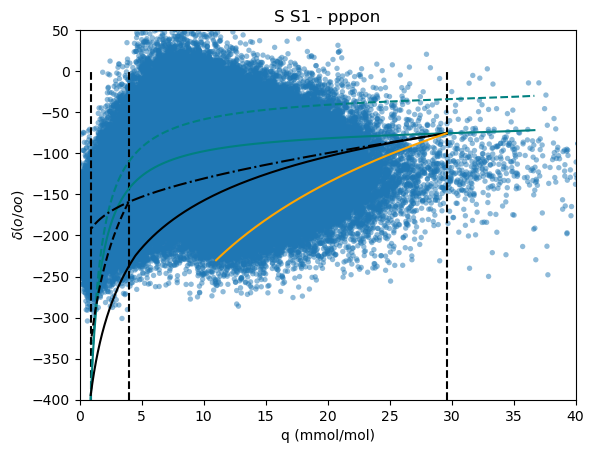

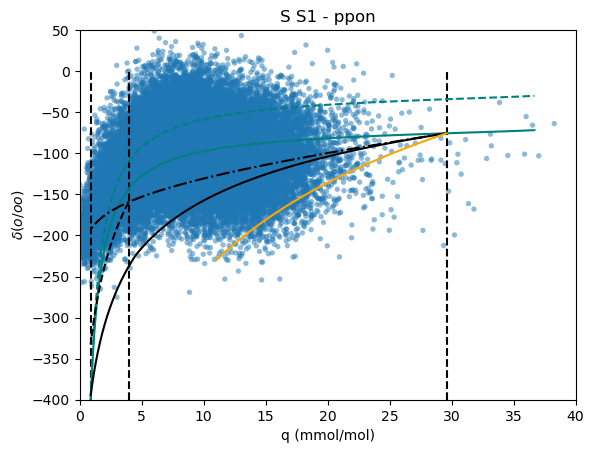

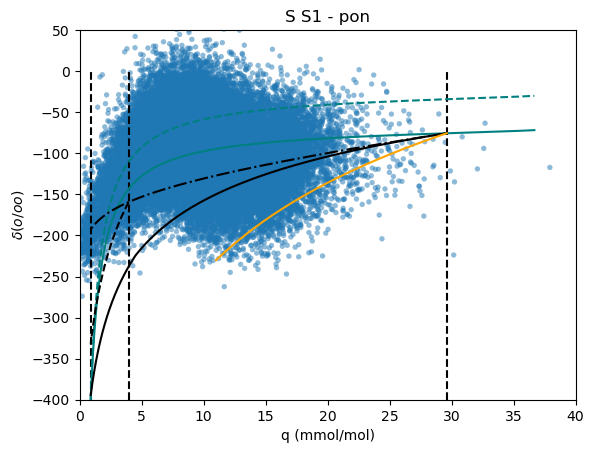

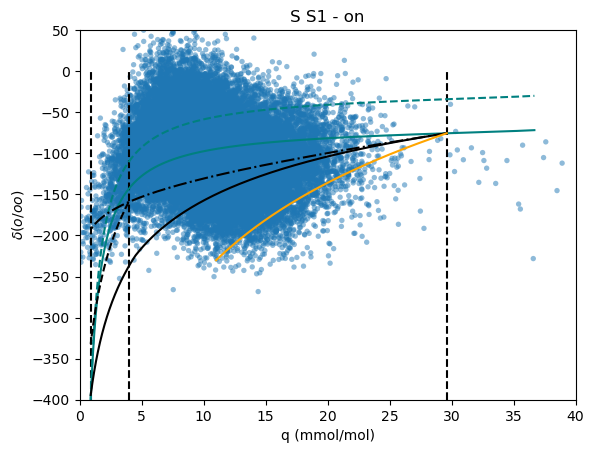

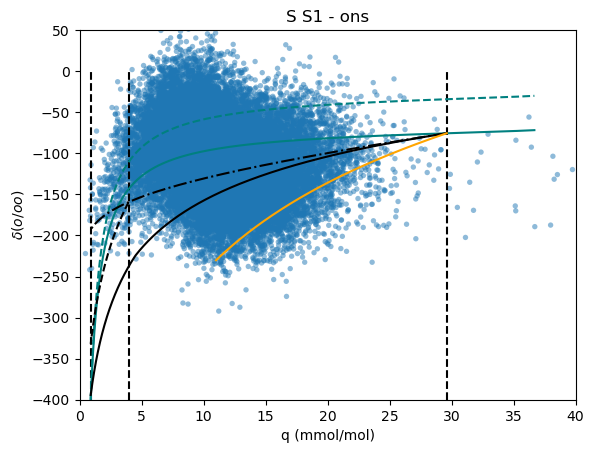

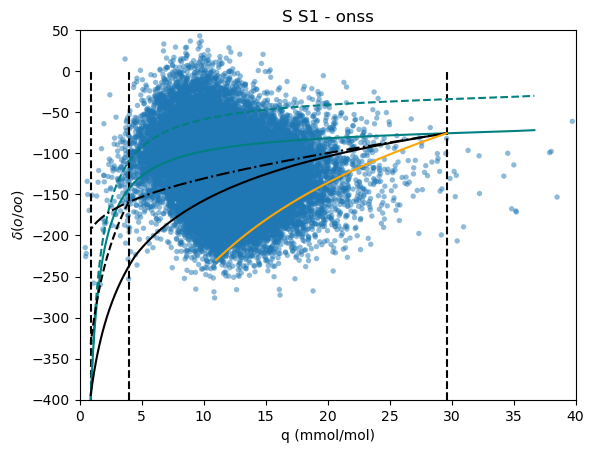

In [181]:
for s in mam_seas:
    
    deltaD = mam_seas[s]['deltaD']
    qh2o = 1000.*mam_seas[s]['H2O']
    
    
    plt.xlim(0,40)
    plt.ylim(-400,50)
    plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.title(band+' S1 - '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S1_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


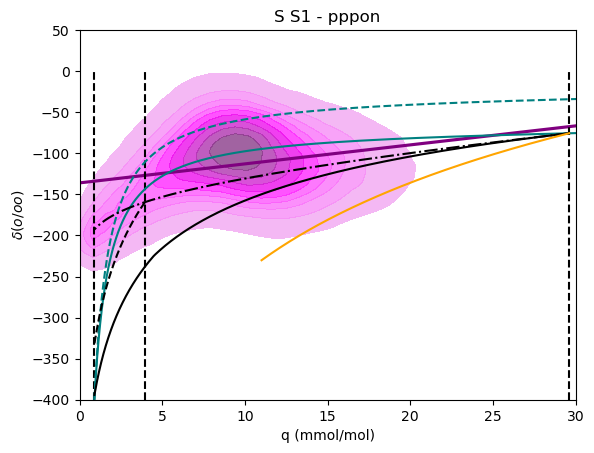

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


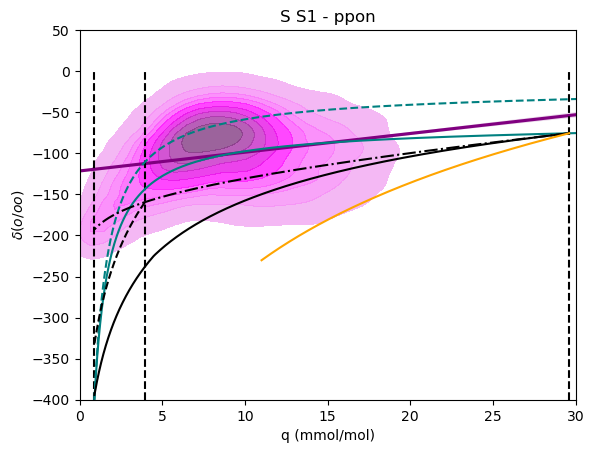

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


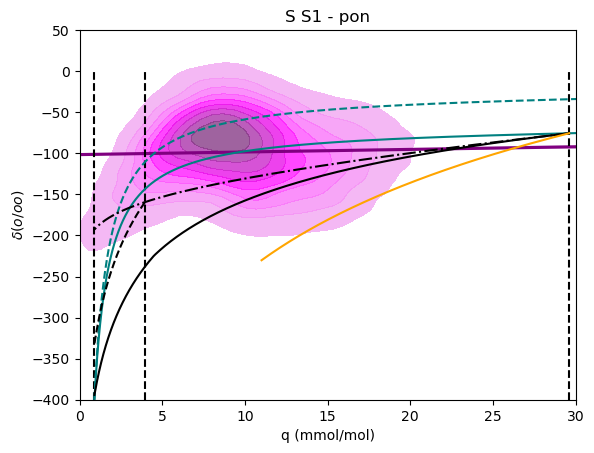

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


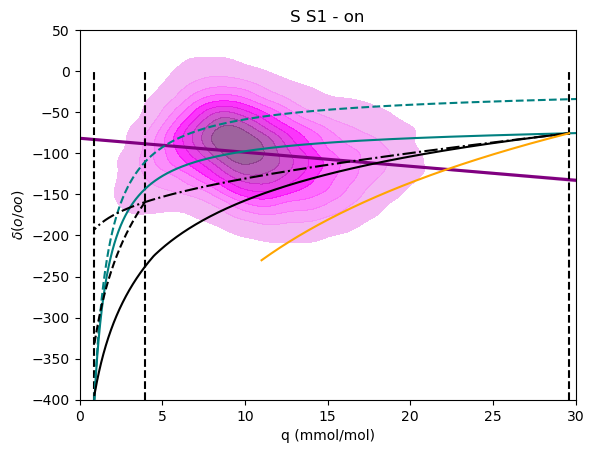

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


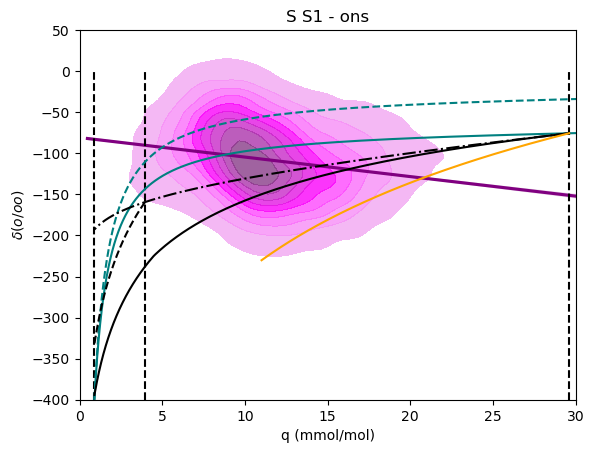

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


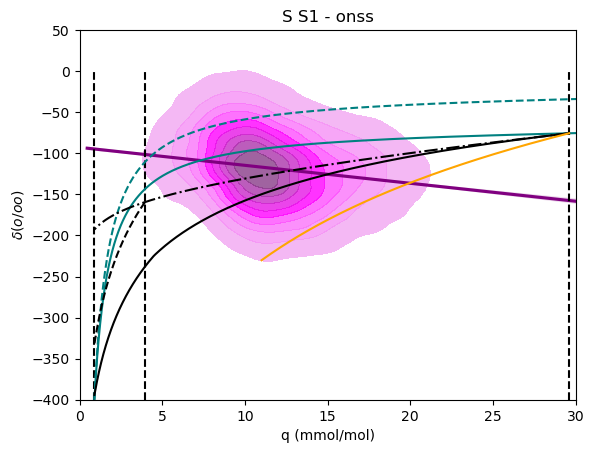

In [182]:
for s in mam_seas:
    
    df = mam_seas[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.
    
    sns.kdeplot(data=df, x="H2O", y="deltaD", fill=True, kind="kde", alpha=0.8,color='purple')
    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple')
    
    plt.xlim(0,30)
    plt.ylim(-400,50)
    #plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.title(band+' S1 - '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S1_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()

In [156]:
ON = 230
pppon = ON-(20*3)
ppon = ON-(20*2)
pon = ON-20
on = ON
ons = ON+20
onss = ON+(20*2)

In [157]:
#SON onset

son_seas = {}
son_seas['pppon'] = tes_ds.where((tes_ds['timedatum.dayofyear']>pppon)&(tes_ds['timedatum.dayofyear']<pppon+20),drop=True)
son_seas['ppon'] = tes_ds.where((tes_ds['timedatum.dayofyear']>ppon)&(tes_ds['timedatum.dayofyear']<ppon+20),drop=True)
son_seas['pon'] = tes_ds.where((tes_ds['timedatum.dayofyear']>pon)&(tes_ds['timedatum.dayofyear']<pon+20),drop=True)
son_seas['on'] = tes_ds.where((tes_ds['timedatum.dayofyear']>on)&(tes_ds['timedatum.dayofyear']<on+20),drop=True)
son_seas['ons'] = tes_ds.where((tes_ds['timedatum.dayofyear']>ons)&(tes_ds['timedatum.dayofyear']<ons+20),drop=True)
son_seas['onss'] = tes_ds.where((tes_ds['timedatum.dayofyear']>onss)&(tes_ds['timedatum.dayofyear']<onss+20),drop=True)


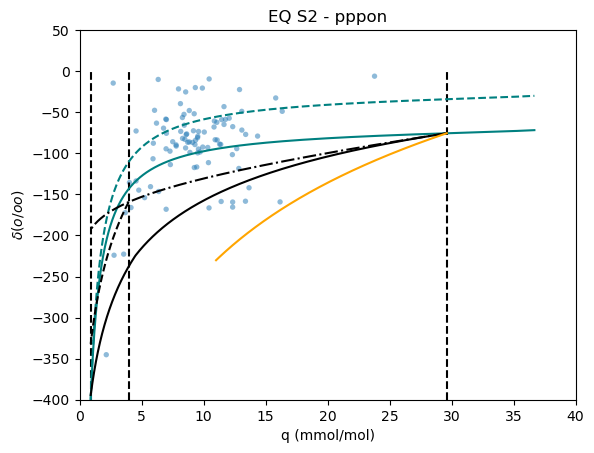

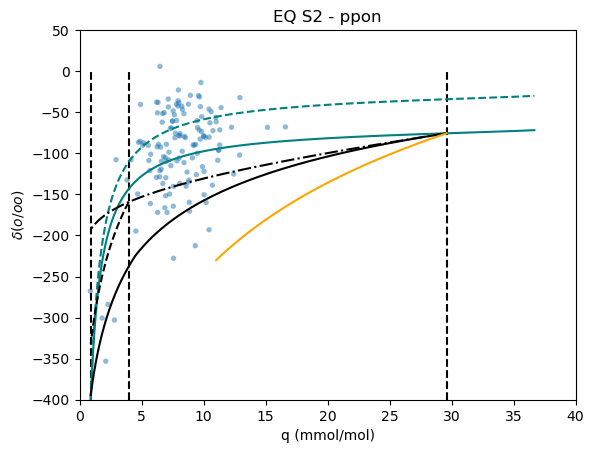

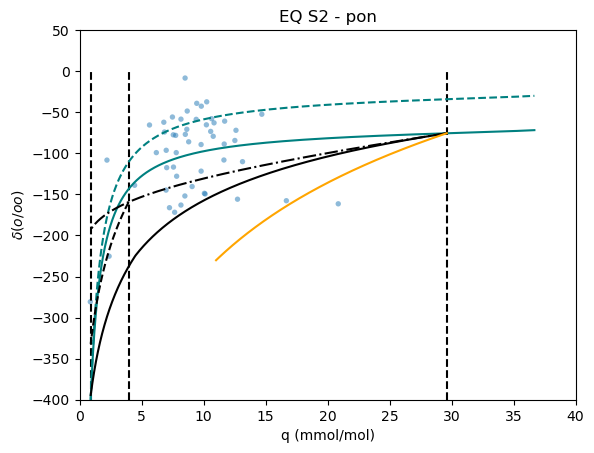

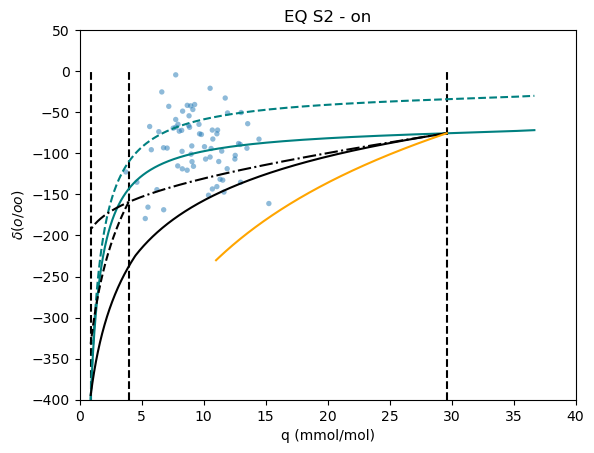

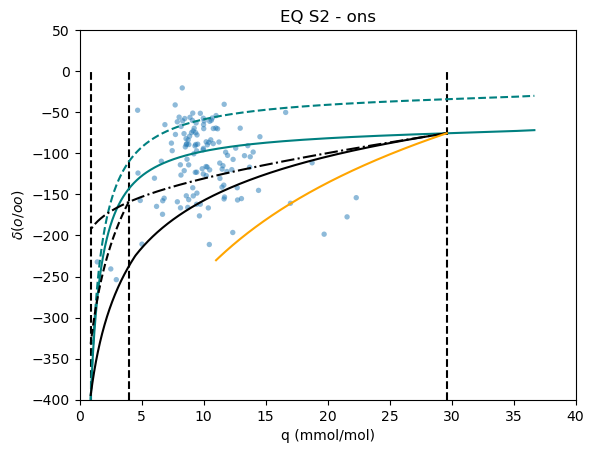

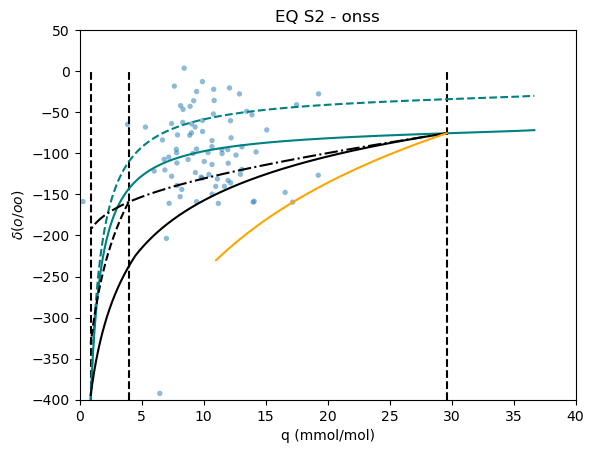

In [158]:
for s in son_seas:
    
    deltaD = son_seas[s]['deltaD']
    qh2o = 1000.*son_seas[s]['H2O']
    
    plt.xlim(0,40)
    plt.ylim(-400,50)
    plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.title(band+' S2 - '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S2_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()
    

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


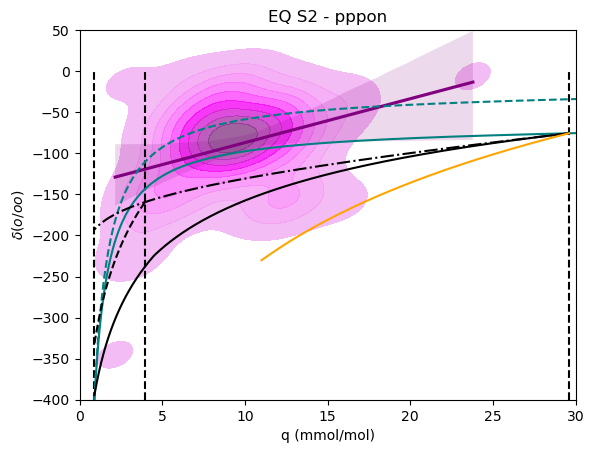

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


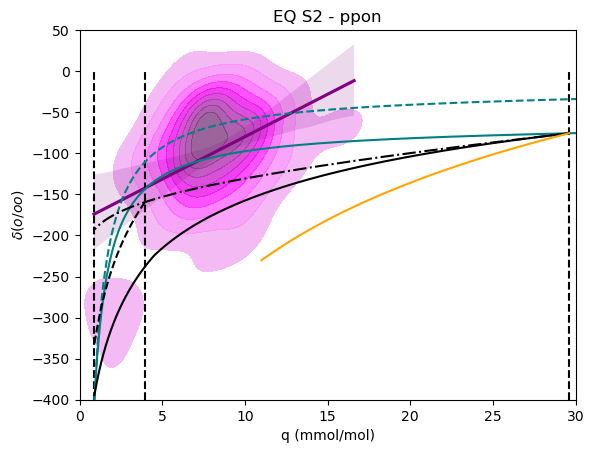

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


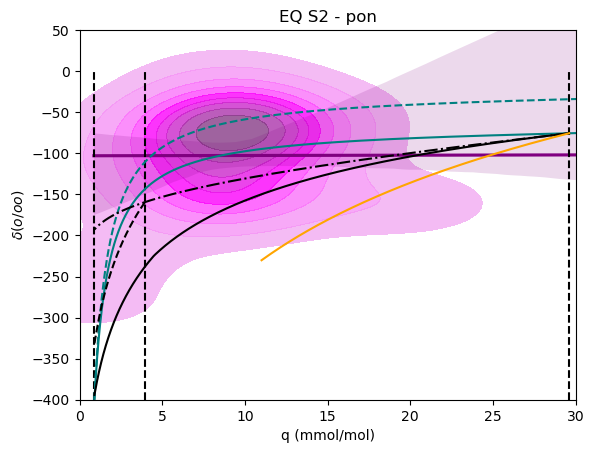

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


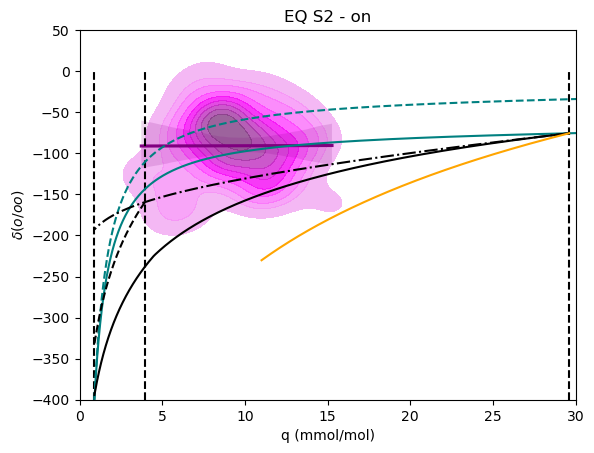

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


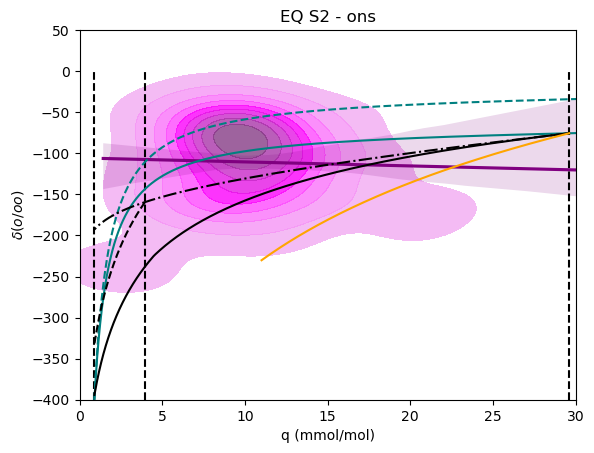

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


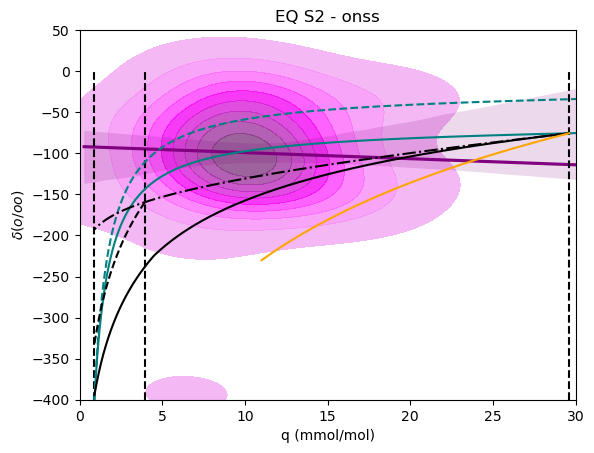

In [159]:
for s in son_seas:
    
    df = son_seas[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.
    
    sns.kdeplot(data=df, x="H2O", y="deltaD", kind="kde", fill=True, alpha=0.8,color='purple')
    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple')
    
    plt.xlim(0,30)
    plt.ylim(-400,50)
    #plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')


    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.title(band+' S2 - '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_S2_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


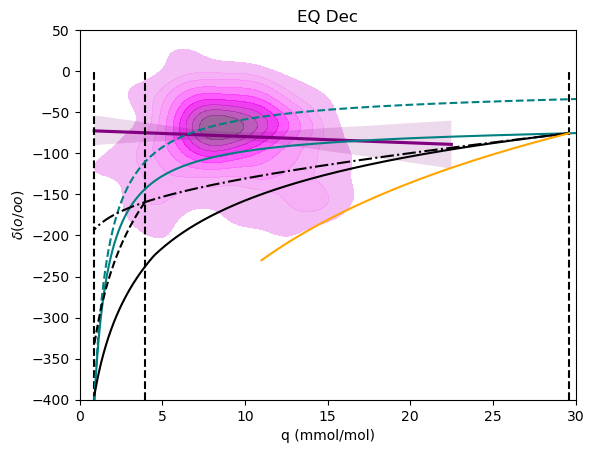

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


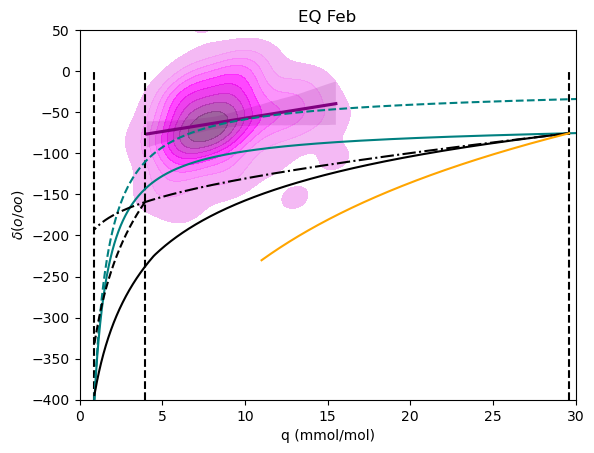

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


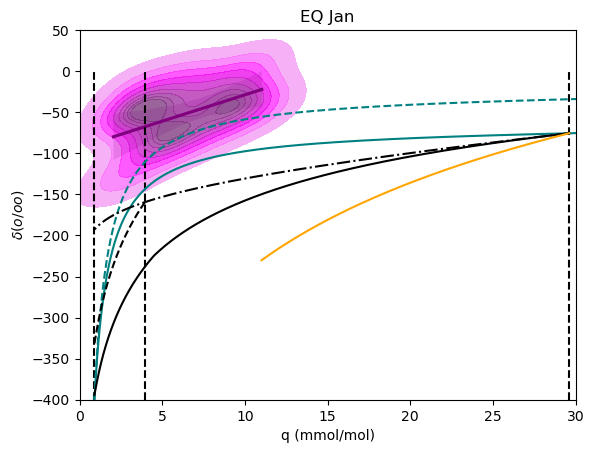

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


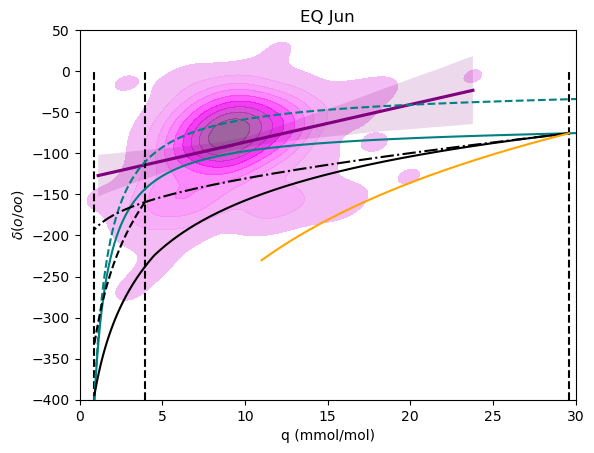

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


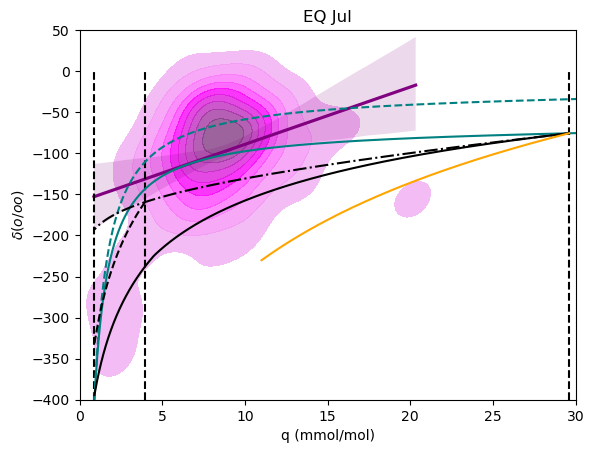

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


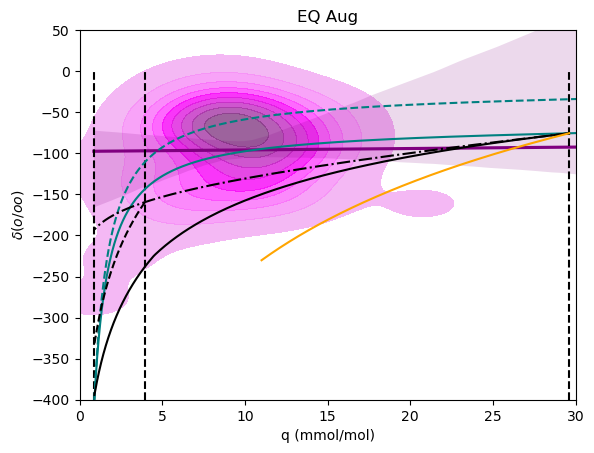

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


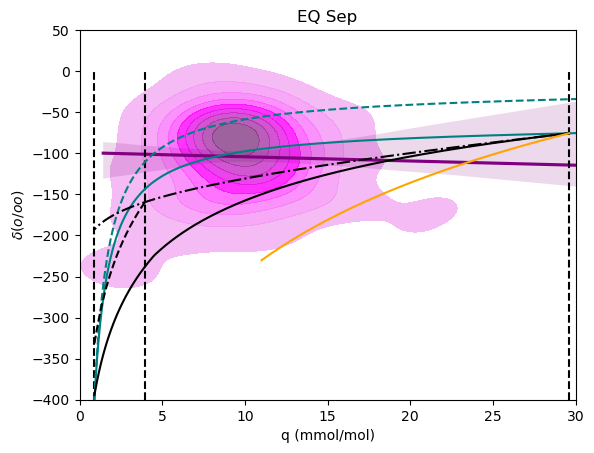

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


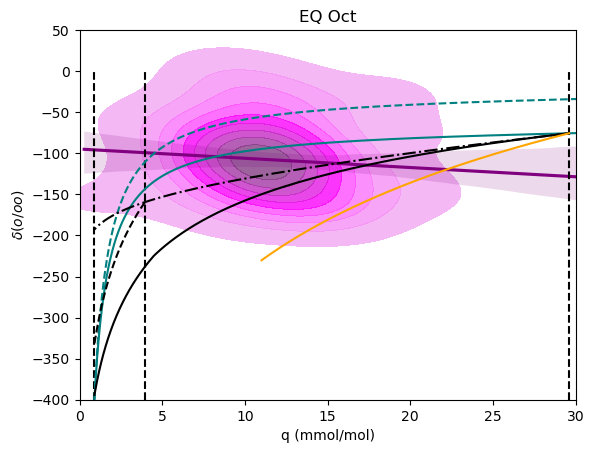

In [160]:
#DJF = tes_ds.where((tes_ds['timedatum.month']>11)&(tes_ds['timedatum.month']<3),drop=True)
#JJA = tes_ds.where((tes_ds['timedatum.month']>5)&(tes_ds['timedatum.month']<9),drop=True)

ext_seas = {}
ext_seas['Dec'] = tes_ds.where((tes_ds['timedatum.month']==12),drop=True)
ext_seas['Feb'] = tes_ds.where((tes_ds['timedatum.month']==2),drop=True)
ext_seas['Jan'] = tes_ds.where((tes_ds['timedatum.month']==1),drop=True)
ext_seas['Jun'] = tes_ds.where((tes_ds['timedatum.month']==6),drop=True)
ext_seas['Jul'] = tes_ds.where((tes_ds['timedatum.month']==7),drop=True)
ext_seas['Aug'] = tes_ds.where((tes_ds['timedatum.month']==8),drop=True)
ext_seas['Sep'] = tes_ds.where((tes_ds['timedatum.month']==9),drop=True)
ext_seas['Oct'] = tes_ds.where((tes_ds['timedatum.month']==10),drop=True)


############

for s in ext_seas:
    
    df = ext_seas[s].to_dataframe()
    df['H2O'] = df['H2O']*1000.
    
    sns.kdeplot(data=df, x="H2O", y="deltaD", kind="kde", fill=True, alpha=0.8,color='purple')
    sns.regplot(data=df, x="H2O", y="deltaD", scatter=False, ci=95, seed=5000, color='purple')
    
    plt.xlim(0,30)
    plt.ylim(-400,50)
    #plt.scatter(qh2o,deltaD,s=15,alpha=0.5,edgecolors='none')

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plt.title(band+' '+s)
    plt.savefig('/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/'+inst+'_noone_curves_'+band+'_'+s+'.png')

    plt.show()
    plt.clf()
    plt.close()


In [161]:
sys.exit()

SystemExit: 

/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:

for m in range(1,13):
    print(m)
    deltaD = tes_ds['deltaD'].groupby('timedatum.month')[m]
    qh2o = 1000.*tes_ds['H2O'].groupby('timedatum.month')[m]
    print(deltaD)
    #deltaD = iso_m['deltaD']
    #qh2o = 1000.*iso_m['H2O']
    plt.xlim(0,55)
    plt.ylim(-600,100)
    plt.scatter(qh2o,deltaD,s=1)

    NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

    plot_file = '/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/plot_noone_curves_'+str(m)+'.png'    # default file name for plots
    plt.title('Month: '+str(m))
    plt.savefig(plot_file)
    
    plt.show()
    plt.clf()


In [ ]:
deltaD_w = tes_ds['deltaD'].groupby('timedatum.weekofyear')
qh2o_w = tes_ds['H2O'].groupby('timedatum.weekofyear')
print(deltaD_w)
#deltaD_roll = tes_ds['deltaD'].rolling(timedatum=10, center=True)   
#deltaD_bin = tes_ds['deltaD'].resample(timedatum='10D')

for m in range(1,53):
    try:
        print(m)
        deltaD = deltaD_w[m]
        qh2o = 1000.*qh2o_w[m]
        print(deltaD)
        plt.xlim(0,55)
        plt.scatter(qh2o,deltaD,s=1)

        plot_file = '/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/plot_noone_curves_week_'+str(m)+'.png'    
        plt.title('Week: '+str(m))
        #plt.savefig(plot_file)

        NC.noone_curves(tsrc,q0,del0)    # Run and produce plot
    
        plt.show()
        plt.clf()
    except:
        print('no week: ',m)